## **Configuración**

En esta sección vamos a configurar el ambiente de cómputo requerido para realizar el análisis de esta parte. La configuración involucra el uso de lenguajes de programación Shell y R contenidos en este Notebook.

Primero, vamos a crear una función llamada shell_call para ejecutar scripts de shell directamente.

Seguido de eso, vamos a instalar y configurar R para asegurarnos de que esté listo para usar.

**R** es un lenguaje de programación y ambiente de software para análisis de datos, estadística, y generación de gráficos. Es ampliamente utilizado en investigación cientígica, aprendizaje de máquina, bioinformática, y ciencia de datos debido a su flexibilidad y vasta colección de paquetes. R es un software de código abierto y ofrece herramientas para manipulación de datos, modelamiento estadístico, visualización, e integración con otros lenguajes como Python y C++.

In [ ]:
# Tutorial original: https://stackoverflow.com/questions/70025153/how-to-access-the-shell-in-google-colab-when-running-the-r-kernel
shell_call <- function(command, ...) {
  result <- system(command, intern = TRUE, ...)
  cat(paste0(result, collapse = "\n"))
}

loadPackages = function(pkgs){
  myrequire = function(...){
    suppressWarnings(suppressMessages(suppressPackageStartupMessages(require(...))))
  }
  ok = sapply(pkgs, require, character.only=TRUE, quietly=TRUE)
  if (!all(ok)){
    message("There are missing packages: ", paste(pkgs[!ok], collapse=", "))
  }
}

## Configuración de R2U

download.file("https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_jammy.sh",
              "add_cranapt_jammy.sh")
Sys.chmod("add_cranapt_jammy.sh", "0755")
shell_call("./add_cranapt_jammy.sh")
bspm::enable()
options(bspm.version.check=FALSE)
shell_call("rm add_cranapt_jammy.sh")

## Instalación de paquetes de R

cranPkgs2Install = c("BiocManager", "ggpubr", "Seurat", "cowplot",
                     "Rtsne", "hdf5r", "clustree", "SoupX")
install.packages(cranPkgs2Install, ask=FALSE, update=TRUE, quietly=TRUE)
biocPkgs2Install = c("clusterProfiler", "preprocessCore", "rols",
                     "scDblFinder","clusterExperiment", "SingleR",
                     "celldex", "org.Hs.eg.db", "DropletUtils")
BiocManager::install(biocPkgs2Install, ask=FALSE, update=TRUE, quietly=TRUE)

#### Paquetes en R

**Paquetes en R**

Un paquete en R es una colección de funciones, datos, y documendación agrupados. Los paquetes ayudan a extender la funcionalidad principal de R al proveer herramientas específicas para diferentes tareas, como análisis de datos, visualización de gráficos, estadística avanzada, etc.


**Instalar**

Antes de usar un paquete, debemos instalarlo en el ambiente de trabajo. Esto se debe hacer sólo una vez (a menos que necesite ser actualizado) con el siguiente comando:

In [ ]:
install.packages("nombre_del_paquete")

**Librería**

Una vez instalado, el paquete necesita ser cargado en cada sesión en la cual desea usarse.
El comando revisa si el paquete en cuestión está instalado. Si el paquete está instalado, este es cargado y queda listo para su uso. Si el paquete no está instalado, R devuelve un error.

Así es como la función library() entra en uso:

In [ ]:
library(nombre_del_paquete)

In [ ]:
# Para simplificar la carga de paquetes, creamos la función loadPackages().
# Pero, si no necesitas tener esta función, debes usar 'library(nombre_del_paquete)'

pkgs = c("Rtsne", "Seurat", "tidyverse", "cowplot",
         "scDblFinder", "clustree", "preprocessCore",
         "clusterProfiler", "celldex", "SoupX")
loadPackages(pkgs)

De esta forma, se han cargado las librerías que instalamos previamente.

* [**Rtsne:**](https://jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) Paquete de R que implementa la técnica de t-SNA para reducción de dimensionalidad y visualización de datos.
* [**Seurat:**](https://satijalab.org/seurat/articles/get_started.html) Seurat es un paquete de R diseñado para control de calidad (quality control; QC), analisis, y exportación de datos de scRNA-seq.
* [**scDblFinder:**](https://bioconductor.org/packages/release/bioc/html/scDblFinder.html) El paquete scDblFinder recopila varios métodos para la detección y manejo de dobletes/multipletes en datos de secuenciación de célula única (múltiples células capturadas en una sola gota o volumnen de reacción)
* [**Cowplot:**](https://wilkelab.org/cowplot/articles/introduction.html) Provee varias característisticas que ayudan con la creación de figuras con calidad para publicación utilizando [`ggplot2`](https://ggplot2.tidyverse.org/index.html), como un set de temas, funciones para alinear gráficos y ordenarlos en figuras compuestas de alta complejidad, y funciones que facilitan la anotación de gráficos y/o mezclar gráficos e imágenes.
* [**clustree:**](https://lazappi.github.io/clustree/) Este visualizador muestra las relaciones entre agrupaciones de células (clusters) en resoluciones múltiples, permitiendo ver cómo las muestras se muecen mientras el número de clusters crece.
* [**PreprocessCore:**](https://bioconductor.org/packages/release/bioc/html/preprocessCore.html)  Una colección de funciones de pre-procesamiento.

## Entrada de datos, matriz dispersa de conteo de UMI

Referencia: https://www.nature.com/articles/s41591-020-0901-9

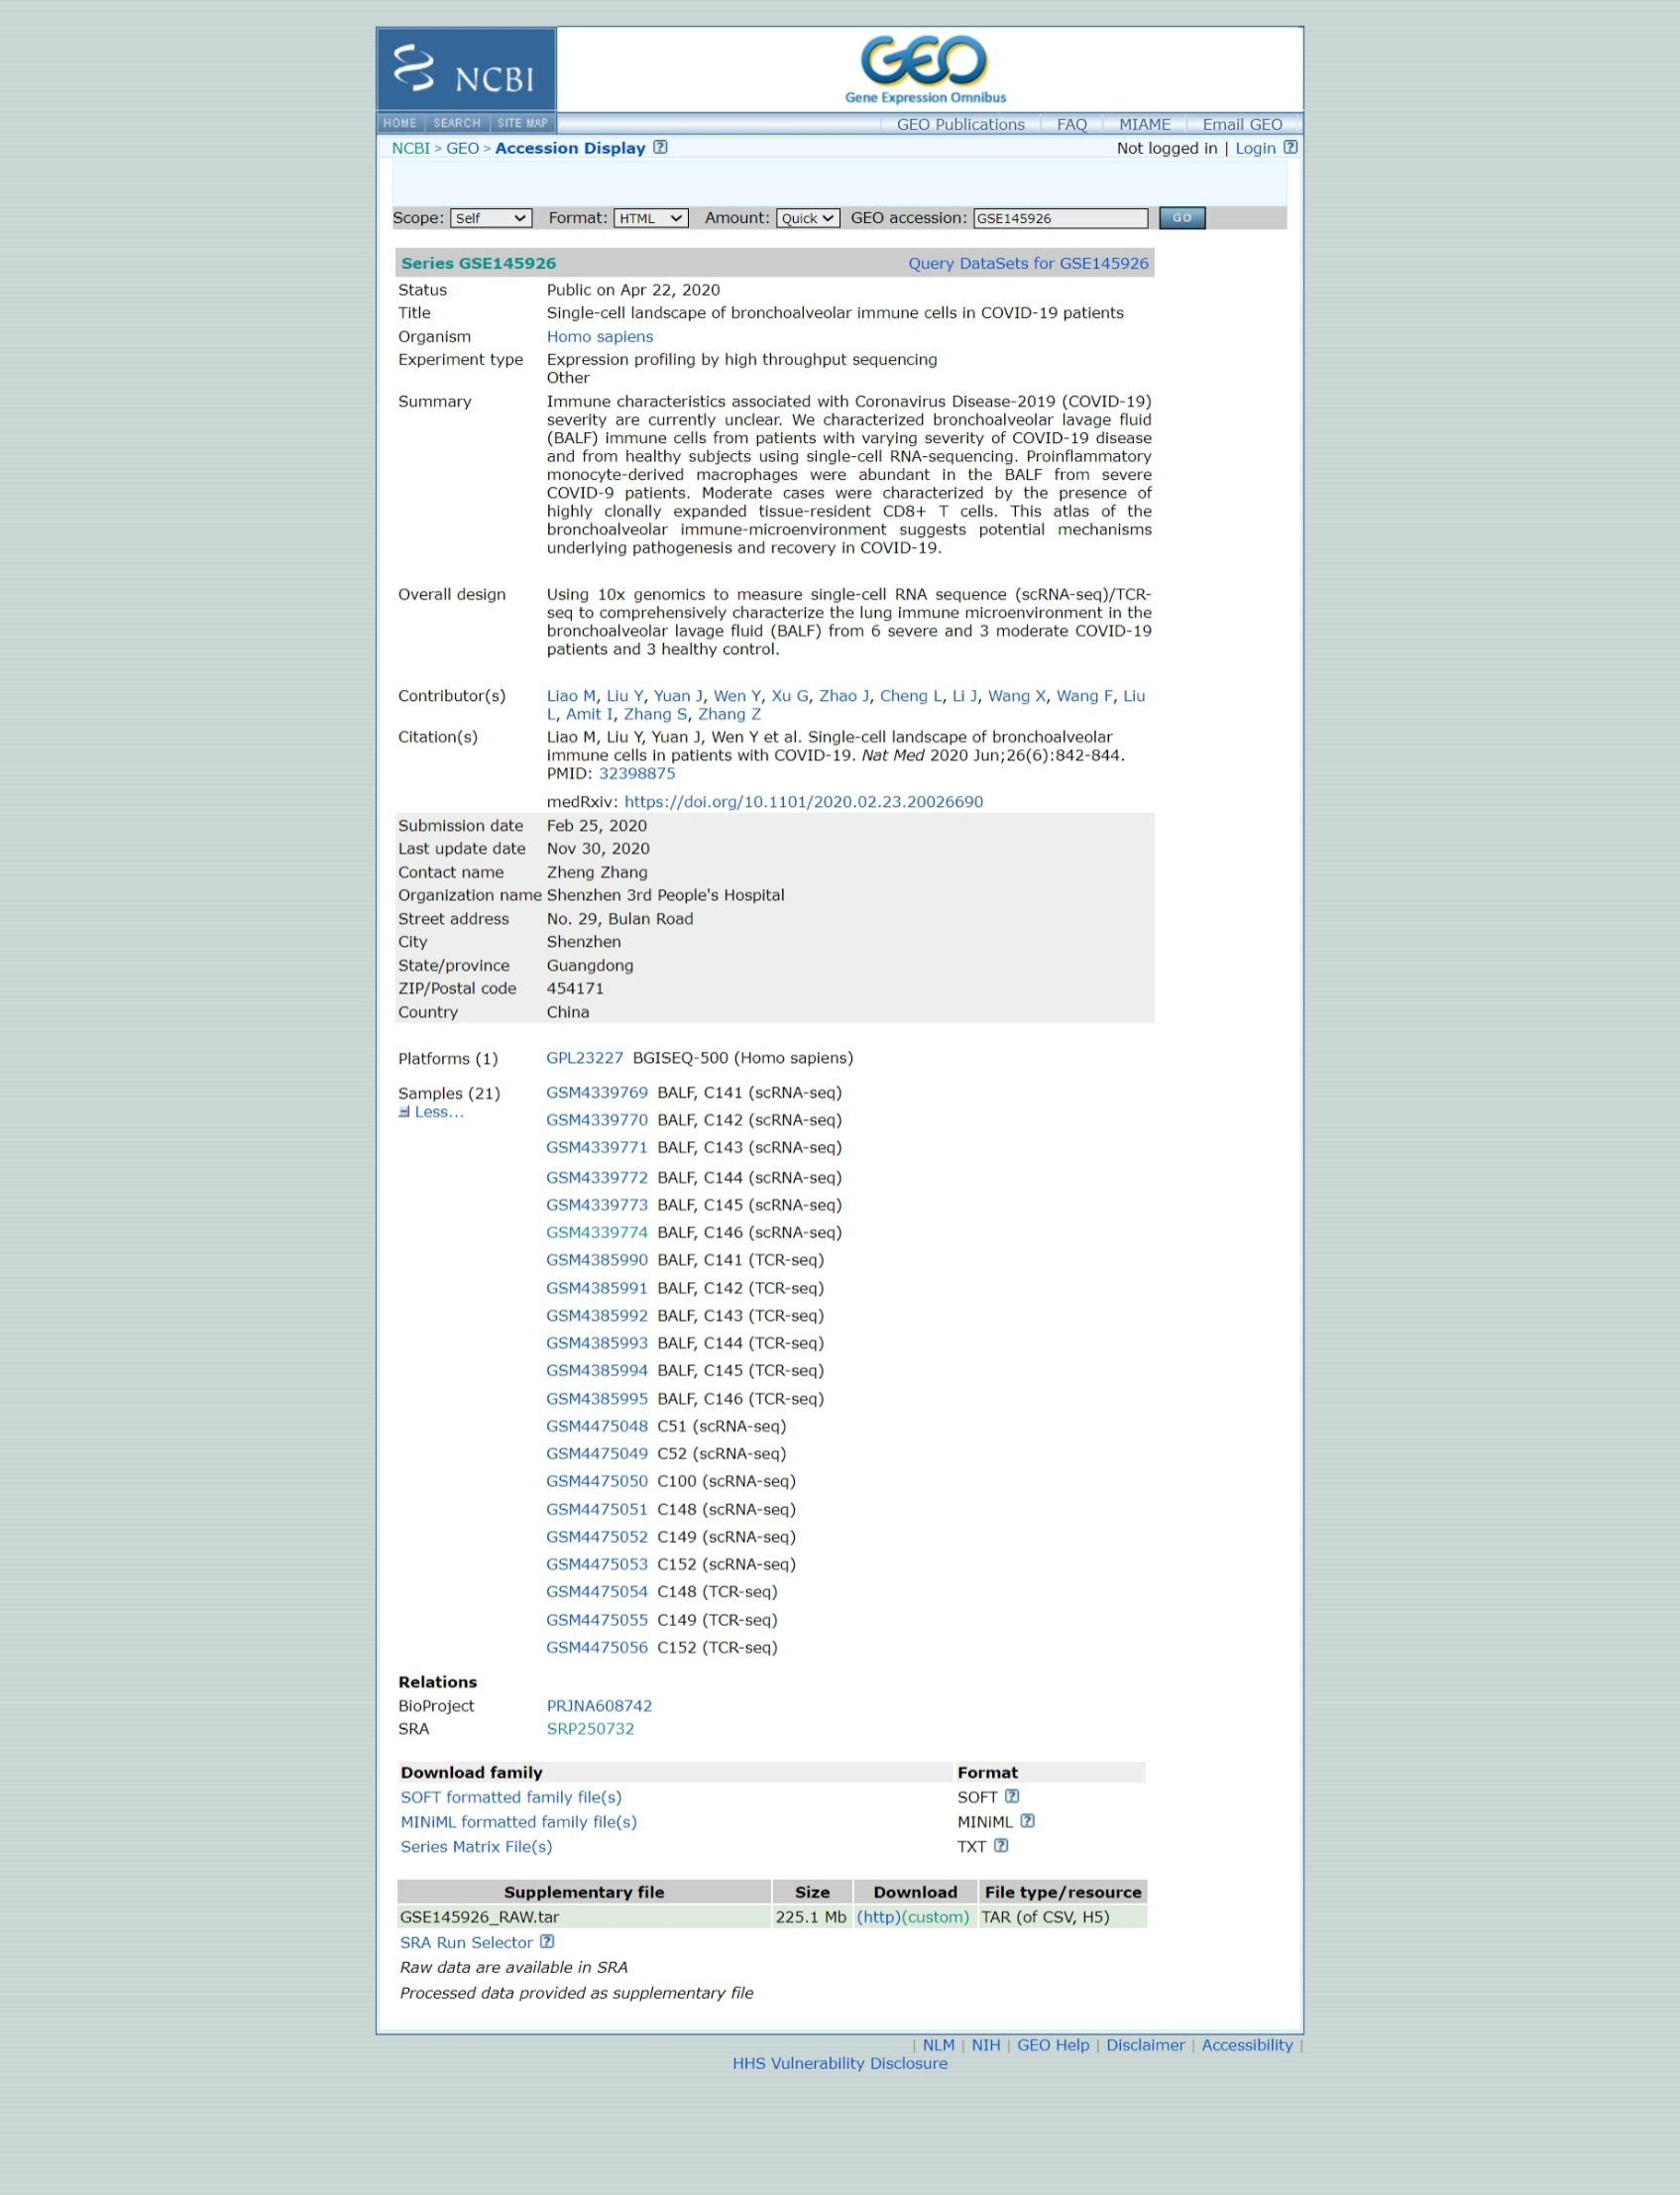

Descargar los datos crudos desde GEO

In [ ]:
# Este comando de R descarga un archivo de internet y lo guarda como archivo local
download.file('https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE145926&format=file','GSE145926_RAW.tar')

# Este comando usa la función personalizada shell_call para ejecutar un comando de shell.
# El comando tar -xf es usado para extraer el contenido de un archivo comprimido en formato .tar.
shell_call("tar -xf GSE145926_RAW.tar")

# rm es un comando de shell para borrar archivos, para liberar espacio y mantener el directorio organizado.
shell_call("rm GSE145926_RAW.tar")

# ls es usado para listar los archivos en un directorio.
# -l: Muestra los detalles de los archivos (permisos, propietario, tamaño, fecha, etc.).
# -h: Formatea el tamaño de los arvhicos a un formato que pueda leer un humano, como KB, MB, o GB.
shell_call("ls -lh")

Separar los archivos de scRNA y TCRseq.

In [ ]:
# Crear un directorio
shell_call("mkdir -p TCRseq")

# mv es el comando de shell para mover o renombrar archivos.
# El patrón *_filtered_contig_annotations.csv.gz usa el caracter comodín "*" para encontrar todos los arvhivos que terminen con "_filtered_contig_annotations.csv.gz".
shell_call("mv *_filtered_contig_annotations.csv.gz TCRseq/")

shell_call("mkdir -p scRNAseq")

#Este comando mueve todos los archivos que contienen "_filtered_" en su nombre al directorio "scRNAseq/".
shell_call("mv *_filtered_* scRNAseq/")
shell_call("ls -lh")

Ahora vamos a leer los datos para una muestra. Los datos de 10X Genomics usualmente son almacenados en el formato HDF5 (Hierarchical Data Format version 5; formato de datos jerárquivos versión 5), es un formato de archivo diseñado para guardar y organizar largos volúmenes de datos eficientemente, siendo un formato de alto rendimiento científico.

El comando Read10X_h5() permite importar estos datos y cargarlos en R, usando un tipo especial de matriz, la cual tiene una forma eficiente de representar los datos con muchos ceros.

Cómo se crearon estos archivos?

In [ ]:
sc <- Read10X_h5("scRNAseq/GSM4339769_C141_filtered_feature_bc_matrix.h5")

In [ ]:
# Notas algo especial en esta matriz?
sc[33493:33500,1:3]

En datos de scRNA-seq, la mayoría de los valores en la matriz son ceros (0), representando genes que no han sido detectados en muchas células. Para manipular esto de forma eficiente, Seurat usa una representación de matriz dispersa cada vez que sea posible.

Las matrices dispersas almacenan sólo los valores diferentes de cero y sus ubicaciones, reduciendo significativamente el uso de memoria y mejorando la velocidad de procesamiento para set de datos como Drop-seq, inDrop, o datos de 10X Genomics.

Por ejemplo, convirtiendo una matriz densa (~1600 MB) a una matriz dispersa reduce su tamaño a menos de 160 MB - una reducción de 10 veces. Esta optimización es crucial cuando se trabaja con set de datos de scRNA-seq de gran escala.

In [ ]:
# Convierte el objeto sc, una matriz dispersa de un set de datos de scRNA-seq, a una matriz densa
dense.size <- object.size(as.matrix(sc))

# Calcula el tamaño del objeto sc sin convertirlo a una matriz densa.
sparse.size <- object.size(sc)

# Entrega el tamaño de ambas matrices en MB
format(dense.size, "MB")
format(sparse.size, "MB")

# Calcula la proporción entre el tamaño de la matríz densa y el tamaño de la matriz dispersa.
dense.size/sparse.size

Usamos los comandos usuales de matriz para manipular una matriz dispersa. A continuación se explica cómo:

Conocer las dimenciones de la matriz;
Identificar la clase de una matriz dispersal;
Seleccionar filas y columnas de una matriz dispersa usando índices numéricos;
Extraer los nombres de las columnas (o filas);
Seleccionar filas (o columnas) de una matriz dispersa usando los nombres de las filas (o columnas)

In [ ]:
# Cuántas características?
# Cuántas células?
dim(sc)

# Cuál es la clase: matriz dispersa
class(sc)

# Seleccionar algunas filas y algunas columnas
# Notas algo especial en esta matriz?
sc[33495:33500,1:3]

# Selecciona los nombres de las filas usando 'rownames' (o 'colnames')
sc[c("MIR1302-2HG","FAM138A","OR4F5"), 1:30]

# Cuáles son los nombres de los genes?
rownames(sc)[1:3]

# Extrae el nombre de las células
colnames(sc)[1:3]

Qué tan grande es esta tabla de cuentas?

In [ ]:
# Muestra las dimensiones de sc
print(dim(sc))

# Muestra la clase de sc
print(class(sc))

## Control de calidad

Ahora crearemos un objeto de Seurat para continuar con el análisis. En este paso, aplicaremos algunos filtros:

1. Remover genes que hayan sido detectados en menos de 3 células
2. Remover células que hayan expresado menos de 200 genes

Estos pasos de filtrado ayudan a limpiar la información al excluir genes y células con expresiones mínimas, las cuáles no serían informativas. Sin embargo, estos filtros son opcionales - uno puede ajustar los límites o saltarse este paso por completo si así se prefiere.

In [ ]:
sampleA <- CreateSeuratObject(counts = sc, project="sampleA", min.cells=3, min.features=200)

In [ ]:
# Métricas de control de calidad (QC) para las primeras 5 células
head(sampleA@meta.data, 5)

Qué es lo que sabemos sobre el objeto "sampleA"?

Cuántos genes y cuántas células tiene este objeto Seurat?

Además, por qué estos números son diferentes?

Recuerda que hemos creado el objeto Seurat especificando que cada gen tiene que estar presente en al menos 3 células (de lo contrario el gen será removido). De la misma forma, especificamos que cada célula debe tener al menos 200 genes expresados.

In [ ]:
sampleA

In [ ]:
# Revisemos las dimensiones de la matriz original (sc)
# y comparemos con el objeto Seurat (sampleA)
dim(sc)
dim(sampleA)
dim(sc) - dim(sampleA)

Cuál es el tamaño de nuestro objeto Seurat?
Cuántos genes y células fueron eliminados de la tabla original?

### Identificación de dobletes

Los dobletes (Doublets) ocurren cuando dos o más células son capturadas por error en el mismo pocillo, lo cual es un problema común en la secuenciación de ARN de célula única. Esto puede suceder cuando la suspensión celular está demasiado concentrada.

Para abordar este problema, utilizaremos el método scDblFinder para identificar y eliminar los dobletes de nuestro conjunto de datos. Este método requiere un objeto de clase SingleCellExperiment, que forma parte de la infraestructura de Bioconductor.

Pasos:
1. Preparar el objeto SingleCellExperiment: Esto es necesario antes de aplicar el método scDblFinder.
2. Aplicar scDblFinder: El método utiliza un enfoque probabilístico para detectar dobletes, por lo que los resultados pueden variar ligeramente entre ejecuciones.
3. Asegurar la reproducibilidad: Para evitar la variabilidad en los resultados, estableceremos una semilla aleatoria usando la función set.seed(). Esto garantiza que el método produzca los mismos resultados cada vez que se ejecute.

Al establecer la semilla, hacemos que el proceso sea reproducible, lo que ayuda a confirmar que los resultados sean consistentes en diferentes ejecuciones.

In [ ]:
sce <- as.SingleCellExperiment(sampleA)
sce

# Necesitamos usar set.seed() porque el comando scDblFinder utiliza una estrategia probabilística para identificar dobles.
# Esto significa que, cada vez que ejecutamos el comando, producirá resultados ligeramente diferentes.
# El comando set.seed() garantizará que se obtengan los mismos resultados cada vez.

set.seed(123)
results <- scDblFinder(sce, returnType = 'table') %>%
  as.data.frame() %>%
  filter(type == 'real')
head(results)

Ten en cuenta que la tabla de resultados incluye una columna llamada "class", la cual categoriza las células en dos tipos: singlete y doblete (singlet y doublet). Como se muestra a continuación, las células dobletes son las cuales deberían ser removidas del set de datos antes de proceder con los análisis posteriores. En otras palabras, queremos conservar sólamente las células etiquetadas como singletes, que representan células individuales, y remover los dobletes.

In [ ]:
results %>%
  dplyr::count(class)

Guardar los resultados de scDblFinder() para usarlos nuevamente después

In [ ]:
# Esta función se utiliza para crear una ruta de archivo de manera robusta, independiente del sistema operativo (funciona en Windows, Linux, etc.).
outfile = file.path('dataset1_control.txt')

# Esta función escribe los datos de un data frame o matriz en un archivo de texto.
write.table(results, outfile, sep='\t', quote=F,
            col.names=TRUE, row.names=TRUE)

Vamos a identificar los dobletes y eliminarlos de nuestra matriz, es decir, vamos a conservar únicamente los singletes.

Recuerda que, en esta sesión, nos estamos enfocando en el objeto Seurat (sampleA), y por eso haremos un subset de este objeto.

In [ ]:
keep = results %>%
  dplyr::filter(class == "singlet") %>%
  rownames()
sampleA = sampleA[, keep]
sampleA

El porcentaje de lecturas mitocondriales no es calculado automáticamente por Cell Ranger. Por lo tanto, primero debemos hacerlo. Aprovechamos esta oportunidad para incluir el porcentaje de lecturas mitocondriales como metadato en el objeto Seurat (sampleA). Recuerda que un porcentaje alto de lecturas mitocondriales generalmente se asocia con células de baja calidad y alto estrés.

In [ ]:
sampleA[["percent.mt"]] <- PercentageFeatureSet(sampleA, pattern="^MT-")

Esta función te permite calcular fácilmente el porcentaje de conteos que pertenecen a un subconjunto específico de características para cada célula. Por ejemplo, puedes usarla para calcular el porcentaje de transcritos que se asignan a genes mitocondriales. El cálculo se realiza sumando los conteos (UMIs) para las características en el subconjunto (por ejemplo, genes mitocondriales) y dividiendo esta suma por la suma total de los conteos para todas las características (todos los genes) en cada célula. El resultado se multiplica por 100 para obtener el porcentaje.

En este ejemplo, la función agrega una nueva columna llamada 'percent.mt' a los metadatos asociados con la muestra (aquí, sampleA). Esta columna contiene el porcentaje calculado para cada célula.

*Clarificación de Terminología:*

**Característica:** Se refiere a los genes en este contexto.

**Conteo:** Se refiere a los conteos de UMI (Identificadores Moleculares Únicos) para cada gen.

In [ ]:
sampleA@meta.data %>% head()

El siguiente código es usado para generar un gráfico de violín para visualizar la distribución de ciertas características en el set de datos, utilizando el paquete de Seurat en R.

In [ ]:
#Esta función se utiliza para crear gráficos de violín, que muestran la distribución de los valores de una característica dada entre las células en un conjunto de datos.

scPlot <- VlnPlot(sampleA, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol=3)
scPlot
#ggsave("01-VlnPlot.png",plot = scPlot, bg = 'white')

Los gráficos de violín unidimensionales comúnmente son difíciles de interpretar en cuanto a la distribución completa, así que probemos con algunos histogramas.  
Esta también es una demostración de cómo hacer gráficos sin usar los comandos de visualización de Seurat.

In [ ]:
sampleA.qc <- FetchData(sampleA,
                        vars=c("nFeature_RNA","nCount_RNA","percent.mt"))
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=100)
scPlot
#ggsave("2-histogram.png",plot = scPlot, bg = 'white')

Intenta extraer el promedio de 'nCounts_RNA'

In [ ]:
summary(sampleA.qc$nCount_RNA)

Vemos con mucha claridad que una célula típica tiene alrededor de 20000 UMIs, pero esto varía desde apenas unas decenas hasta más de 60000.

Vamos a acercarnos al extremo inferior de los conteos bajos para ver si podemos identificar alguna estructura (por ejemplo, bimodalidad).

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=100) +
          xlim(0,1500)
scPlot
#ggsave("03-histogram.png",plot = scPlot, bg = 'white')

Dado al amplio rango dinámico, probablemente una escala logaritmica sea útil.

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=nCount_RNA), bins=200) +
          scale_x_log10()
scPlot
#ggsave("04-histogram.png",plot = scPlot, bg = 'white')

Ahora veamos la número mediano de genes por célula.

In [ ]:
median(sampleA.qc$nFeature_RNA)

In [ ]:
scPlot <- sampleA.qc %>%
    ggplot() +
    geom_histogram(aes(x=nFeature_RNA), bins=200) +
    geom_vline(xintercept = 3096,color="red")
scPlot
#ggsave("05-histogram.png",plot = scPlot, bg = 'white')
scPlot <- sampleA.qc %>%
    ggplot() +
    geom_histogram(aes(x=nFeature_RNA), bins=200) +
    geom_vline(xintercept = 10^(3.491),color="red") +
    scale_x_log10()
scPlot
#ggsave("06-histogram.png",plot = scPlot, bg = 'white')
summary(sampleA.qc$nFeature_RNA)

Parece que una célula típica tiene datos de aproximadamente 3000 genes, variando desde 200 (el mínimo que establecimos al crear el objeto Seurat) hasta más de 9000.

Y qué hay del porcentaje de lecturas mitocondriales?

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_histogram(aes(x=percent.mt), bins=100) +
          geom_vline(xintercept = 10,color="red")
scPlot
#ggsave("07-histogram.png",plot = scPlot, bg = 'white')
summary(sampleA.qc$percent.mt)

La mayoría de las células están por debajo del **5%**, pero algunas superan el **50%**.

A menudo es más útil observar múltiples métricas de control de calidad (QC) juntas en lugar de individualmente. Probemos con algunos gráficos de dispersión 2D simples.

In [ ]:
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="percent.mt")
scPlot
#ggsave("08-FeatureScatter.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="nFeature_RNA")
scPlot
#ggsave("09-FeatureScatter.png",plot = scPlot, bg = 'white')

Recuerda: no necesitamos usar exclusivamente las herramientas para graficar de Seurat.

ggplot2 es una herramienta de visualización poderosa, que maneja tablas de manera eficiente para crear gráficos. Observa el gráfico anterior (nFeature vs. nCount) y considera que podría ser interesante entender cómo se comportan los datos en función del porcentaje de lecturas mitocondriales (MT reads).

In [ ]:
scPlot <- sampleA.qc %>%
          ggplot() +
          geom_point(aes(nCount_RNA, nFeature_RNA, colour=percent.mt), alpha=.50) +
          scale_x_log10() +
          scale_y_log10()
scPlot
#ggsave("10-FeatureScatter.png",plot = scPlot, bg = 'white')

La mayoría de estas métricas de control de calidad (QC) se ven bastante bien. De acuerdo a estas métricas, no observamos subpoblaciones de células notablemente diferentes.
Solo para estar seguros, eliminemos las células con más del 10% de lecturas mitocondriales, ya que esto puede ser un indicio de daño ex-vivo durante la manipulación de la muestra y la generación de la librería.

In [ ]:
#Filter using more than one variable
sampleA <- subset(sampleA, nCount_RNA > 500 & nFeature_RNA < 7000 & percent.mt < 10)

Reutilicemos el gráfico que creamos en el último ejercicio y creemos una nueva columna (llamada 'keep' (conservar)) usando la tabla de metadatos. Esta columna identificará las células que eliminamos anteriormente.

In [ ]:
scPlot <- sampleA.qc %>%
          mutate(keep = if_else(nCount_RNA > 500 & nFeature_RNA < 7000 & percent.mt < 10, "keep", "remove")) %>%
          ggplot() +
          geom_point(aes(nCount_RNA, nFeature_RNA, colour=keep), alpha=.50) +
          scale_x_log10() +
          scale_y_log10()
scPlot
#ggsave("11-point.png",plot = scPlot, bg = 'white')

In [ ]:
#sampleA <- subset(sampleA, subset = percent.mt < 10)
scPlot <- FeatureScatter(sampleA, feature1="nCount_RNA", feature2="percent.mt")
scPlot
#ggsave("12-FeatureScatter.png",plot = scPlot, bg = 'white')
print(dim(sc))
print(dim(sampleA))


## Normalización
La variación en el ARN total por célula probablemente puede influir en los resultados. Esto es algo que podriamos observar en nuestros pasos de control de calidad (QC), y dado que aún no hemos corregido por esto, es importante abordar este problema ahora.

Una forma común y directa de corregir esto es normalizar los datos. Lo haremos dividiendo los conteos para cada gen por el conteo total de UMI (Identificador Molecular Único) para esa célula específica. Este paso ajusta la eficiencia de captura de ARN que varía entre células, asegurando que los niveles de expresión sean comparables entre todas las células, independientemente de su contenido total de ARN.

Después de la normalización, aplicaremos una transformación logarítmica. Esto se hace para hacer que los datos sean más manejables y reducir el impacto de los genes con expresión muy alta, los cuales pueden dominar el análisis.

Adicionalmente, multiplicaremos los conteos normalizados por un factor de escala de 10,000 antes de aplicar la transformación logarítmica. Este factor es algo arbitrario, pero es comúnmente utilizado en la práctica. El factor de escala asegura que los valores resultantes no sean demasiado pequeños y sean más fáciles de manejar computacionalmente. Aunque el factor exacto no es crítico, usar un valor estándar como 10,000 hace que el proceso sea consistente y permite una comparación más fácil entre conjuntos de datos.

Pero antes guardemos una version sin normalizar, que nos servira mas adelante para comparar ...

In [ ]:
unnormalized <- sampleA

ahora, ya podemos proceder

In [ ]:
sampleA <- NormalizeData(sampleA, normalization.method="LogNormalize",
                        scale.factor=10000)

## Identificar genes variables

*Comencemos explorando algunas visualizaciones para tener una idea de los patrones de cambio en la expresión de genes entre células.*

Uno de los primeros pasos en el análisis es identificar los genes que muestran mayor variabilidad a lo largo del conjunto de datos. Los genes que no varían mucho entre células tienen menos probabilidad de aportar información útil para análisis posteriores, por lo que nos enfocaremos en los 2000 genes más variables.

Para ello, primero aplicaremos una transformación de estabilización de la varianza (vst). Esta transformación ayuda a ajustar la relación entre la media y la varianza de los valores de expresión génica, facilitando la comparación entre genes con diferentes niveles de expresión. El objetivo de 'vst' es reducir el efecto de los genes con niveles altos de expresión, que tienden a tener mayor variabilidad, y hacer que la variabilidad de la expresión de genes sea más consistente entre diferentes niveles de expresión. Este paso asegura que podamos identificar con mayor precisión los genes que realmente varían entre células y que probablemente sean biológicamente significativos.

In [ ]:
sampleA <- FindVariableFeatures(sampleA, selection.method = "vst", nfeatures = 2000)

Ahora, veamos los nombres de los genes con mayor variabilidad.

In [ ]:
top10 <- head(VariableFeatures(sampleA), 10)
top10

Grafiquemos la varianza (luego de 'vst') en comparación al promedio de expresión para cada gen, coloreando el top 2000 y etiquetando el top 10.

In [ ]:
plot1 <- VariableFeaturePlot(sampleA)
scPlot <- LabelPoints(plot=plot1, points = top10, repel=T, xnudge=0, ynudge=0) + theme(legend.position="none")
scPlot
#ggsave("13-VariableFeaturePlot.png",plot = scPlot, bg = 'white')

## Escalando la expresión de genes

El siguiente paso en el análisis es escalar la expresión de cada gen a través de las células. Esto significa ajustar los valores de expresión de manera que cada gen tenga una expresión media de 0 y una varianza de 1. Este paso de escalado es importante porque los genes suelen tener diferentes niveles de expresión (magnitud), y si no escalamos los datos, los genes con niveles de expresión más altos podrían dominar el análisis.

Al escalar la expresión, todos los genes contribuirán de manera equitativa en los análisis posteriores, independientemente de sus niveles de expresión iniciales. Esta es una técnica comúnmente utilizada en muchos campos en los que se manejan grandes volúmenes de datos para asegurar que las características (como los genes en este caso) con diferentes escalas o magnitudes puedan compararse o utilizarse juntas de manera efectiva.

En Seurat, el proceso de escalado no sobrescribe los valores originales de expresión no escalados. En cambio, los valores de expresión escalados se almacenan por separado en el objeto Seurat bajo `sampleA[["RNA"]]$scale.data`. De esta manera, tanto los valores de expresión crudos como los escalados se preservan, lo que te permite usar cualquiera de las dos versiones dependiendo del análisis o visualización que estés realizando.

Escalar los datos

In [ ]:
sampleA <- ScaleData(sampleA)

Por default, solo se escalan los genes mas variables, los cuales se usan para analisis posteriores como la reduccion de dimensiones.

In [ ]:
sampleA[["RNA"]]$data[1:10,1:10]

# Reducción de dimensiones

## PCA

Hemos identificado los genes más variables y estandarizado sus escalas. Ahora, realicemos nuestra primera reducción de dimensionalidad y visualización utilizando PCA (Análisis de Componentes Principales).

PCA es una técnica utilizada para reducir el número de dimensiones (características) en un conjunto de datos, mientras se preserva la mayor cantidad posible de variabilidad (información). Lo hace encontrando nuevas variables, llamadas componentes principales, que son combinaciones de las características originales. Estos componentes capturan los patrones más importantes en los datos. En términos simples, PCA ayuda a simplificar datos complejos transformándolos en un conjunto más pequeño de componentes significativos, lo que facilita su visualización e interpretación.

**Realizar PCA**

In [ ]:
sampleA <- RunPCA(sampleA, features = VariableFeatures(sampleA))
scPlot <- DimPlot(sampleA, reduction="pca")
scPlot
#ggsave("14-DimPlot.png",plot = scPlot, bg = 'white')

La varianza explicada por cada componente principal es la relación entre cada valor propio (eigenvalue) y la suma de todos los valores propios. Debemos recordar que Seurat no calcula todos los componentes principales, ya que es computacionalmente pesado. En nuestro caso, calculó los primeros 50 componentes principales (PCs), por lo que toda la inferencia debe ser condicional a estos 50 PCs.

Calcular la varianza de cada componente

In [ ]:
pca = sampleA[["pca"]]

## get the eigenvalues
evs = pca@stdev^2
total.var = pca@misc$total.variance
varExplained = evs/total.var
pca.data = data.frame(PC=factor(1:length(evs)),
                      percVar=varExplained*100)
pca.var = cumsum(pca.data$percVar)
######
pca.data$cumulVar = pca.var
# pca.data$cumulVar = cumsum(pca.data$percVar) <- retire '#' para funcionar

head(pca.data, 20)

scPlot <- pca.data[1:10,] %>%
          ggplot(aes(x=PC, y=percVar)) +
          geom_bar(stat='identity') +
          geom_hline(yintercept = 1, colour="red", linetype=3) +
          labs(title="Variance Explanation by PCA") +
          xlab("Principal Components") +
          ylab("Percentage of Explained Variance") +
          theme_bw()
scPlot
#ggsave("15-geom_bar.png",plot = scPlot, bg = 'white')

scPlot <- pca.data[1:10,] %>%
          ggplot(aes(x=PC, y=cumulVar)) +
          geom_bar(stat='identity') +
          geom_hline(yintercept = 50, colour="red", linetype=3) +
          labs(title="Cumulative Variance Explanation by PCA") +
          xlab("Principal Components") +
          ylab("Cumulative Percentage of Explained Variance") +
          theme_bw()
scPlot
#ggsave("16-geom_bar.png",plot = scPlot, bg = 'white')

Tal vez podamos aprender algo al observar qué genes contribuyen a esas componentes principales (PCs).

In [ ]:
#png("17-DimHeatmap.png", res= 300, height = 1920, width = 1920)
DimHeatmap(sampleA, dims = 1:2)
#dev.off()

 ¿Cómo se ven los otros PCs?

In [ ]:
#png("18-DimHeatmap.png", res= 300, height = 1920, width = 1920)
DimHeatmap(sampleA, dims = 1:5, cells = 500, balanced=T)
#dev.off()

##### Comparaciones
¿Como afecta la normalizacion a los datos?
primero preparemos los datos no normalizados al punto en que se encuentra nuestro dataset

In [ ]:
unnormalized[["RNA"]]$data <- unnormalized[["RNA"]]$counts

Lo anterior reemplaza la capa de informacion que necesita ScaleData() para **funcionar**

In [ ]:
unnormalized <- FindVariableFeatures(unnormalized, selection.method = "vst", nfeatures = 2000)
unnormalized <- ScaleData(unnormalized)
unnormalized <- RunPCA(unnormalized, features = VariableFeatures(unnormalized))

Visualicemos segun la informacion de la cantidad de UMIs por celula, que es el efecto que se busca corregir

In [ ]:
NormalizeDataPlot <- FeaturePlot(sampleA, features="nCount_RNA")
UnnormPlot <- FeaturePlot(unnormalized, features="nCount_RNA")
options(repr.plot.width=12, repr.plot.height=6) # Cambio en la relacion de aspecto ara una mejor vista de los 2 featureplots
UnnormPlot | NormalizeDataPlot

¿Que podriamos decir de esta figura?

##### Normalizacion Alternativa
Satijalab desarrollo una metodo propio de normalizacion implementado en Seurat el cual llamaron 'sctransform' (PMID: 31870423), el cual describen con una mejor capacidad para corregir las diferencias en la profundidad de secuenciacion, informacion complementaria en https://satijalab.org/seurat/articles/sctransform_vignette.html

El siguiente comando cumple las mismas funciones de NormalizeData(), ScaleData(), y FindVariableFeatures(), cabe destacar que el metodo se ejecuta de esta forma al ser solo una muestra/individuo, para multiples es necesario hacer algunas modificaciones segun el diseño experimental https://satijalab.org/seurat/archive/v4.3/sctransform_v2_vignette

In [ ]:
BiocManager::install('glmGamPoi')
sampleA <- SCTransform(sampleA, verbose = T)

Ahora podemos notar que en la salida de ejecucion de la herramienta nos informa "Set default assay to SCT", lo que implica nuevo "assay" en el objeto de R, este assay contiene tambien 3 capas de informacion relativas a la expression (counts, data y scaled.data) al igual que el assay "RNA" que habiamos estado utilizando, pero transformados segun el metodo de sctransform.

In [ ]:
sampleA$RNA
sampleA$SCT

In [ ]:
class(sampleA$RNA)

In [ ]:
class(sampleA$SCT)

In [ ]:
sampleA$RNA$data[1:5,1:20]
sampleA$SCT$data[1:5,1:20]

Actualmente el Assay activo es "SCT" pero puedes volver a seleccionar "RNA"

In [ ]:
DefaultAssay(sampleA) <- "RNA"
sampleA

y volver a "SCT"

In [ ]:
DefaultAssay(sampleA) <- "SCT"
sampleA

Esto influye en donde buscaran los datos las funciones de Seurat, aunque tambien podemos definirlo en ellas, como en RunPCA() donde explicitamos el uso del Assay "SCT", este argumento por default es NULL, lo que implica como ya mencionamos el uso del assay activo, tambien se modifico el nombre de la reduccion para no sobreescribir el pca generado con los datos del assay "RNA". Puedes revisar argumentos para esta y otras funciones en la pagina de Seurat https://satijalab.org/seurat/reference/

In [ ]:
sampleA <- RunPCA(sampleA, features = VariableFeatures(sampleA), assay = "SCT", reduction.name = "SCT.pca")

In [ ]:
sctransform <- FeaturePlot(sampleA, features="nCount_RNA", reduction = "SCT.pca")
sctransform | NormalizeDataPlot

## UMAP

UMAP (Aproximación y Proyección de Variedad Uniforme; Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad no lineal que se usa con frecuencia para visualizar conjuntos de datos complejos, como los datos de scRNA-seq. A diferencia de PCA, que es una transformación lineal, UMAP es capaz de capturar relaciones más complejas y no lineales entre los puntos de datos. Esto hace que UMAP sea especialmente útil cuando los datos tienen estructuras intrincadas que no pueden ser capturadas por métodos lineales.

La característica de UMAP es que preserva tanto las estructuras locales como globales en los datos. Esto significa que UMAP no solo mantiene las relaciones entre los puntos cercanos, sino que también trata de conservar la estructura general más amplia del conjunto de datos, lo que lo hace excelente para la visualización.

Sin embargo, el inconveniente o limitación de UMAP es que es computacionalmente costoso y puede generar ruido cuando se trabaja directamente con datos de alta dimensionalidad. Para abordar esto, a menudo realizamos una reducción dimensional inicial utilizando PCA antes de aplicar UMAP. PCA reduce el número de dimensiones al identificar los componentes más importantes en los datos, lo que simplifica la estructura y acelera los cálculos de UMAP. Además, PCA puede ayudar a eliminar algo de ruido, mejorando la calidad de los resultados de UMAP.

En resumen, UMAP es una herramienta poderosa para visualizar datos complejos, y usarla después de PCA puede hacer que el proceso sea más eficiente y producir resultados más claros.

In [ ]:
# Para usar PCA en la reducción de dimensionalidad, debemos elegir cuántos componentes principales usar.
# Dado que PCA es lineal y ortogonal, los valores de los componentes principales son fáciles de interpretar como la
# fracción de la variación total en los datos.
# Veamos los principales componentes.
scPlot <- ElbowPlot(sampleA)
options(repr.plot.width=6, repr.plot.height=6) # Cambio en la relacion de aspecto a la default de colab
scPlot
#ggsave("23-ElbowPlot.png",plot = scPlot, bg = 'white')

o podemos verlo generado para los datos con sctransform

In [ ]:
scPlot <- ElbowPlot(sampleA, reduction = "SCT.pca")
scPlot

In [ ]:
# Por defecto vemos el top 20, pero podemos mostrar más si así lo deseamos.
scPlot <- ElbowPlot(sampleA, ndims=50)
scPlot
#ggsave("24-ElbowPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Ten en cuenta que el RunPCA anterior solo calculó los 50 primeros. Si queremos ver más valores de componentes
# principales, primero debemos calcularlos.
# Podríamos regresar y volver a ejecutar el PCA, pero por cuestiones de tiempo, usaremos solo los 50 primeros.

# Aunque no hay un límite claro (raramente lo hay), no parece que todos los 50 primeros sean esenciales.
# Nuestros cálculos, por supuesto, serán más rápidos si usamos solo 2 PCs, veamos qué efecto tiene eso.

DefaultAssay(sampleA) <- "RNA" # IMPORTANTE: por simplicidad seguiremos trabajando principalmente con el assay "RNA"
sampleA <- RunUMAP(sampleA, dims=1:2, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("25-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Eso parece sospechoso. No coincide en absoluto con nuestras expectativas sobre cómo deberían ser los perfiles de
# expresión génica de los subconjuntos de PBMC.
# Veamos si es un patrón robusto, o si cambia mucho cuando agregamos solo un PC más.

sampleA <- RunUMAP(sampleA, dims=1:3, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("26-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# De hecho, cambió bastante! Pero aún no coincide realmente con lo que podríamos esperar
# para los PBMCs. Además, el gráfico de los valores de los PCs anteriores no se estabiliza hasta algún punto
# en el rango de 15 a 25. Usaremos los primeros 20.

sampleA <- RunUMAP(sampleA, dims=1:20, verbose=F)
scPlot <- DimPlot(sampleA, label=T) + NoLegend()
scPlot
#ggsave("26-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
# ¡Algunos buenos grupos! Primero, aseguremos que ninguno de ellos sea consecuencia de artefactos de control de calidad.

scPlot <- FeaturePlot(sampleA, features=c("percent.mt"))
scPlot
#ggsave("25-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("nCount_RNA"))
scPlot
#ggsave("26-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Esto se ve bien. No parece que ni el porcentaje de lecturas mitocondriales ni el total de UMI por célula estén
# dominando ninguna de las estructuras que vemos en el UMAP.

# Mientras exploramos, veamos los primeros PCs.
# Aunque tanto UMAP como PCA están, en cierto sentido, tratando de encontrar variaciones naturales en los datos,
# son cálculos muy diferentes y no debemos asumir que están (o no están) relacionados.

scPlot <- FeaturePlot(sampleA, features=c("PC_1"))
scPlot
#ggsave("27-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("PC_2"))
scPlot
#ggsave("28-FeaturePlot.png",plot = scPlot, bg = 'white')

Ahora veamos algunos genes individuales. Para un enfoque no supervisado, podríamos comenzar con algunos de los genes más variables.

In [ ]:
top10

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[1:4], ncol=2)
scPlot
#ggsave("29-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[5:8], ncol=2)
scPlot
#ggsave("30-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=top10[9:10], ncol=1)
scPlot
#ggsave("31-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# También podemnos ver algunos de los genes pertenecientes a los primeros PCs
print(sampleA[["pca"]], dims=1:5, nfeatures=2)

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("CTSC", "CD52", "LRRIQ1", "EFCAB1"))
scPlot
#ggsave("32-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("CD68", "SERPING1", "IL32", "CD3E"))
scPlot
#ggsave("33-FeaturePlot.png",plot = scPlot, bg = 'white')

# Agrupamiento (clustering)

El *clustering* es un método utilizado en análisis de datos para agrupar objetos (como células, genes u otras entidades) en función de sus similitudes. En el contexto de datos de scRNA-seq, el *clustering* ayuda a identificar poblaciones celulares distintas agrupando células con perfiles de expresión génica similares. Ahora, realicemos un *clustering* formal sobre estos datos. Aunque existen varios algoritmos disponibles, utilizaremos un enfoque basado en un grafo de vecinos más cercanos combinado con el algoritmo de Louvain para identificar clústeres o comunidades dentro de los datos.

Este método funciona construyendo un grafo en el que cada punto de datos (célula) está conectado a sus vecinos más cercanos, y luego se aplica el algoritmo de Louvain para encontrar grupos de puntos que están densamente conectados entre sí, lo cual indica la presencia de clústeres.

Una ventaja de este enfoque es que se basa en métricas de distancia hacia los vecinos más cercanos, lo que lo hace relativamente robusto frente a la *maldición de la dimensionalidad*. Esto significa que tiene mejor rendimiento que otros algoritmos cuando se trabaja con datos de alta dimensionalidad, como los datos de scRNA-seq, donde la gran cantidad de variables puede complicar el agrupamiento. Por lo tanto, el grafo de vecinos más cercanos y el algoritmo de Louvain son una buena opción para detectar clústeres significativos en conjuntos de datos complejos.

Calcularemos las distancias de las primeras 20 dimensiones.

In [ ]:
sampleA <- FindNeighbors(sampleA, dims=1:20)
sampleA <- FindClusters(sampleA)

Ahora visualizaremos la pertenencia a clústeres en el espacio UMAP.

In [ ]:
scPlot <- DimPlot(sampleA, reduction="umap")
scPlot
#ggsave("34-DimPlot.png",plot = scPlot, bg = 'white')

Casi todos los algoritmos de *clustering* tienen algún tipo de parámetro libre que controla cuántos clústeres se identifican.

En el algoritmo de Louvain, ese parámetro es la *resolución*, por medio de esta, manteniendo constantes todos los demás parámetros (como las dimensiones, el número de vecinos más cercanos, etc.), controla la cantidad de clústeres. Valores bajos (altos) de resolución producen una menor (mayor) cantidad de clústeres.

In [ ]:
# Exploremos esto.
sampleA <- FindClusters(sampleA, resolution=0.01)

In [ ]:
scPlot <- DimPlot(sampleA, reduction="umap")
scPlot
#ggsave("35-DimPlot.png",plot = scPlot, bg = 'white')

In [ ]:
sampleA <- FindClusters(sampleA, resolution=10)

In [ ]:
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("36-DimPlot.png",plot = scPlot, bg = 'white')

Puede ser útil ver cómo los clústeres correspondientes a un valor de *resolución* se relacionan con los de otra *resolución*. El paquete clustree hace un buen trabajo visualizando esto sobre los agrupamientos (*clusterings*) que ya hemos realizado.

In [ ]:
head(sampleA[[]])

In [ ]:
scPlot <- clustree(sampleA,prefix="RNA_snn_res.")
scPlot
#ggsave("37-clustree.png",plot = scPlot, bg = 'white', width = 16, height = 9)

In [ ]:
sampleA <- FindClusters(sampleA, resolution=seq(0.1, 2, by=0.1))

In [ ]:
scPlot <- clustree(sampleA,prefix="RNA_snn_res.")
scPlot
#ggsave("38-clustree.png",plot = scPlot, bg = 'white', width = 16, height = 9)

Ahora volvamos a la resolución que nos resultó en tres clústeres.

In [ ]:
sampleA <- FindClusters(sampleA,resolution=0.01)
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("39-DimPlot.png",plot = scPlot, bg = 'white')

Así es cómo podemos identificar genes marcadores para el clúster 0

In [ ]:
devtools::install_github("immunogenomics/presto") # Intalar esto aumentara la velocidad de FindMarkers()

In [ ]:
cluster0.markers <- FindMarkers(sampleA, ident.1=0, min.pct=0.25)
head(cluster0.markers)

In [ ]:
scPlot <- FeaturePlot(sampleA,features="CES1")
scPlot
#ggsave("40-FeaturePlot.png",plot = scPlot, bg = 'white')

Como no especificamos, el cálculo anterior nos dio genes significativamente sobreexpresados o subexpresados en nuestra población de interés. A veces solo queremos los genes sobreexpresados, lo cual es fácil de filtrar.

In [ ]:
cluster0.markers <- FindMarkers(sampleA, ident.1=0, min.pct=0.25,only.pos=T)
head(cluster0.markers, 10)

In [ ]:
scPlot <- FeaturePlot(sampleA, features="CORO1A")
scPlot
#ggsave("41-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("LIMD2"))
scPlot
#ggsave("42-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features=c("CD48"))
scPlot
#ggsave("43-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# It's always good to try multiple different visualizations.
scPlot <- VlnPlot(sampleA, features=c("CORO1A", "LIMD2", "CD48"))
scPlot
#ggsave("44-VlnPlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- sampleA %>%
          FetchData(vars=c("CORO1A", "seurat_clusters")) %>%
          ggplot() +
          geom_histogram(aes(x=CORO1A), bins=100) +
          facet_wrap(. ~ seurat_clusters)
scPlot
#ggsave("45-histogram.png",plot = scPlot, bg = 'white')

In [ ]:
# Encontremos los genes marcadores sobreexpresados para todos los clústeres.
sampleA.markers = FindAllMarkers(sampleA, only.pos=TRUE,
                            min.pct=0.25, logfc.threshold=0.25)
head(sampleA.markers)
topMarkers <- sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)
scPlot <- DoHeatmap(sampleA, features = topMarkers$gene) + NoLegend()
scPlot
#ggsave("46-DoHeatmap.png",plot = scPlot, bg = 'white')

In [ ]:
# Si aumentamos un poco la resolución, obtenemos una separación más detallada de las nubes en el UMAP.
sampleA <- FindClusters(sampleA, resolution=0.2)

In [ ]:
scPlot <- DimPlot(sampleA)
scPlot
#ggsave("47-DoHeatmap.png",plot = scPlot, bg = 'white')

# Expresión diferencial

La expresión diferencial se refiere al proceso de identificar genes que muestran diferencias significativas en los niveles de expresión entre distintos grupos de células o condiciones. Este análisis ayuda a descubrir genes que se expresan de manera única en tipos celulares específicos, en ciertos estados, o en respuesta a determinados tratamientos o factores ambientales.

In [ ]:
# Veamos si el clúster 2 y el clúster 0 realmente tienen diferentes patrones de expresión génica
# y, si es así, si estos coinciden con alguna comportamiento biológico que ya conozcamos y que podríamos
# esperar ver en los PBMCs.

cluster1vs0 <- FindMarkers(sampleA, ident.1 = 2, ident.2 = 0)
head(cluster1vs0, 20)

In [ ]:
scPlot <- FeaturePlot(sampleA, features="MCEMP1")
scPlot
#ggsave("48-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
scPlot <- FeaturePlot(sampleA, features="CXCL11")
scPlot
#ggsave("49-FeaturePlot.png",plot = scPlot, bg = 'white')

In [ ]:
# Observa que CXCL11 también se expresa en otro grupo. Los habíamos ignorado al buscar genes
# diferencialmente expresados entre los clústeres 2 y 0, por lo que esto no debería ser sorprendente.
sampleA.markers = FindAllMarkers(sampleA, only.pos=TRUE, min.pct=0.25)
topMarkers = sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)
scPlot <- DoHeatmap(sampleA, features = topMarkers$gene) + NoLegend()
scPlot
#ggsave("50-DoHeatmap.png",plot = scPlot, bg = 'white')

In [ ]:
topMarkers = sampleA.markers %>%
  group_by(cluster) %>%
  top_n(n=5, wt=avg_log2FC)
scPlot <- DoHeatmap(sampleA, features = c("CXCL11", topMarkers$gene)) + NoLegend()
scPlot
#ggsave("51-DoHeatmap.png",plot = scPlot, bg = 'white')

# Anotación de tipos celulares

Interpretar los resultados del análisis de datos de célula única suele ser la parte más desafiante del proceso. Para obtener una comprensión más profunda, más allá de los clústeres que hemos identificado, podemos anotar los tipos celulares comparando los perfiles de expresión de nuestros datos con un conjunto de datos de referencia. Este enfoque nos permite proporcionar interpretaciones con mayor significado para los clústeres.

Para comenzar, cargaremos un conjunto de datos de referencia que incluye los tipos celulares que esperamos encontrar en nuestras muestras. El paquete celldex ofrece varios conjuntos de datos de referencia bien curados y bien anotados. Aunque la mayoría de estos conjuntos de datos provienen de experimentos de *bulk RNA-Seq* y microarrays, siguen siendo muy útiles para anotar conjuntos de datos de célula única. En nuestro caso, utilizaremos los conjuntos de datos de referencia Blueprint y ENCODE, que son comúnmente utilizados para estos fines. Estos conjuntos de datos nos ayudarán a emparejar los perfiles de expresión génica de nuestros datos de célula única con tipos celulares conocidos, mejorando nuestra capacidad para interpretar los clústeres de manera significativa.

In [ ]:
library(celldex)
ref = BlueprintEncodeData()
ref

Luego, para usar la función `SingleR()`, necesitamos convertir el objeto `Seurat` a un objeto `SingleCellExperiment` de Bioconductor. La función `SingleR()` toma nuestro conjunto de datos, el conjunto de datos de referencia y las etiquetas del conjunto de datos de referencia.

In [ ]:
library(SingleR)
my.sce = as.SingleCellExperiment(sampleA)
pred = SingleR(my.sce, ref=ref, labels=ref$label.main)
table(pred$labels)

Podemos usar un mapa de calor (heatmap) para visualizar la anotación de tipo celular resultante. En la parte superior del heatmap, vemos el código de colores que identifica los diferentes tipos celulares.

In [ ]:
#png("52-plotScoreHeatmap.png", res = 300, width = 1920, height = 1920)
plotScoreHeatmap(pred)
#dev.off()

Un heatmap también puede usarse para mostrar la distribución de los tipos celulares por los clústeres que identificamos usando `Seurat`.

In [ ]:
my.table = table(Assigned=pred$pruned.labels,
                 cluster=my.sce$seurat_clusters)
my.table
library(pheatmap)
pheatmap(log2(my.table + 1), filename = "53-pheatmap.png")

# Análisis de enriquecimiento de términos GO

El análisis de enriquecimiento es una herramienta poderosa para extraer información biológicamente relevante de los conjuntos de datos de células únicas, facilitando el descubrimiento de genes clave, vías y procesos celulares. En scRNA-seq, los investigadores suelen tratar con tejidos complejos compuestos por varios tipos celulares. Este análisis puede revelar nuevos conocimientos biológicos al resaltar asociaciones inesperadas entre conjuntos de genes y términos de la Ontología Génica (GO, por sus siglas en inglés, Gene Ontology), proporcionando una comprensión más profunda de las funciones celulares y los mecanismos de enfermedades.

El Análisis de Enriquecimiento GO es un método utilizado para identificar términos GO sobrerrepresentados dentro de un conjunto de genes. Este análisis ayuda a determinar si ciertos procesos biológicos, funciones moleculares o componentes celulares están significativamente asociados con los genes de interés.

La Ontología Génica (GO) es un sistema integral que categoriza los genes en categorías jerárquicas según:

* Procesos Biológicos (BP): Los objetivos biológicos a los que el gen contribuye, como el ciclo celular, la apoptosis o el metabolismo.

* Funciones Moleculares (MF): Las actividades moleculares realizadas por el producto génico, como la unión o la actividad catalítica.

* Componentes Celulares (CC): El lugar dentro de la célula donde el producto génico está activo, como el núcleo o el mitocondrion.

In [ ]:
# Filtrado de genes

my.genes = sampleA.markers %>%
  filter(abs(avg_log2FC) > 1, # Esta condición retiene las filas donde el valor absoluto del cambio promedio en log2 es mayor a 1
         p_val_adj < 0.10) %>% # Esta condición retiene las filas donde el valor p ajustado es menor a 0.10
  dplyr::select(gene) %>% # La función select del paquete dplyr se usa para seleccionar la columna de genes de los datos filtrados.
  pull() # La función pull extrae los valores de la columna seleccionada de genes como un vector

# Mostrar las primeras filas
head(my.genes)

In [ ]:
nrow(sampleA.markers) # Esta función entrega el número de filas
genes <- sampleA.markers %>% arrange(desc(avg_log2FC)) # Ordenar los datos en orden descendente basado en la columna que indica el promedio de cambio en log2.
# Mostrar las primeras filas
head(genes)

In [ ]:
library(clusterProfiler) # Proporciona funciones para la clasificación de términos biológicos y el análisis de enriquecimiento.

# Convertir identificadores de genes
my.map = bitr(my.genes, # Esta función convierte los identificadores de genes de un tipo a otro
              fromType="SYMBOL", # Especifica que los identificadores de genes de entrada son símbolos de genes
              toType="ENTREZID", # Especifica que la salida debe ser en formato Entrez ID
              OrgDb="org.Hs.eg.db") # Especifica la base de datos de organismos para genes humanos

# Mostrar las primeras entradas
head(my.map)

# Calcular el número de genes no mapeados
length(my.genes) - nrow(my.map)

### Clasificación por términos GO

In [ ]:
# Subontologías: Biological Process (BP; procesos biológicos), Molecular Function (MF; función molecular), Cellular Component (CC; componente celular)
library(org.Hs.eg.db) # Librería que contiene anotaciones para genes humanos.
# Agrupa los genes en función de sus términos GO
ggo_bp = groupGO(gene     = my.map$ENTREZID, # Especifica la lista de ID de genes ENTREZ para agrupar
                 OrgDb    = org.Hs.eg.db,
                 ont      = "BP", # Especifica que el agrupamiento GO debe basarse en la subontología de "Proceso Biológico".
                 readable = TRUE) # Convierte los IDs de Entrez a símbolos de genes para una interpretación más fácil.

# Muestra las primeras entradas del objeto ggo_bp
head(ggo_bp)

In [ ]:
# Subontologias: BP, MF, CC
ggo_mf = groupGO(gene     = my.map$ENTREZID,
                 OrgDb    = org.Hs.eg.db,
                 ont      = "MF", # Especifica que el agrupamiento GO debe basarse en la subontología de "Función Molecular".
                 readable = TRUE)

# Muestra las primeras pocas entradas del objeto ggo_mf
head(ggo_mf)

In [ ]:
# Subontologias: BP, MF, CC
ggo_cc = groupGO(gene     = my.map$ENTREZID,
                 OrgDb    = org.Hs.eg.db,
                 ont      = "CC", # Especifica que el agrupamiento GO debe basarse en la subontología de "Componente Celular".
                 readable = TRUE)


# Muestra las primeras pocas entradas del objeto ggo_cc
head(ggo_cc)

### Análisis de sobrerepresentación de términos GO

In [ ]:
# Esta función realiza el análisis de enriquecimiento de términos GO en un set de genes dado.
ego <- enrichGO(gene          = my.map$ENTREZID,
                OrgDb         = org.Hs.eg.db,
                ont           = "BP",
                pAdjustMethod = "BH", # El método utilizado para ajustar los valores p para controlar la tasa de descubrimiento falso (FDR)
                pvalueCutoff  = 0.01, # El umbral de valor p para significancia
                qvalueCutoff  = 0.05, # El umbral de valor q para significancia
        readable      = TRUE)
head(ego)

# Correccion de ARN Ambiental (Opcional)
En algunos casos puede existir sospecha de que los datos presenten contaminacion desde celulas que se destruyeron y liberaron su contenido al medio en el momento de preparar las librerias, lo que podria alterar las cuentas de ARNs en las celulas integras. Herramientas como SoupX (PMID: 33367645) se encargan de analizar los barcodes que se detectaron como background y su contenidos de ARNs, con la finalidad de identificar transcritos potencialmente incrementados por contaminacion en los barcodes detectados como celulas y corregir su efecto.

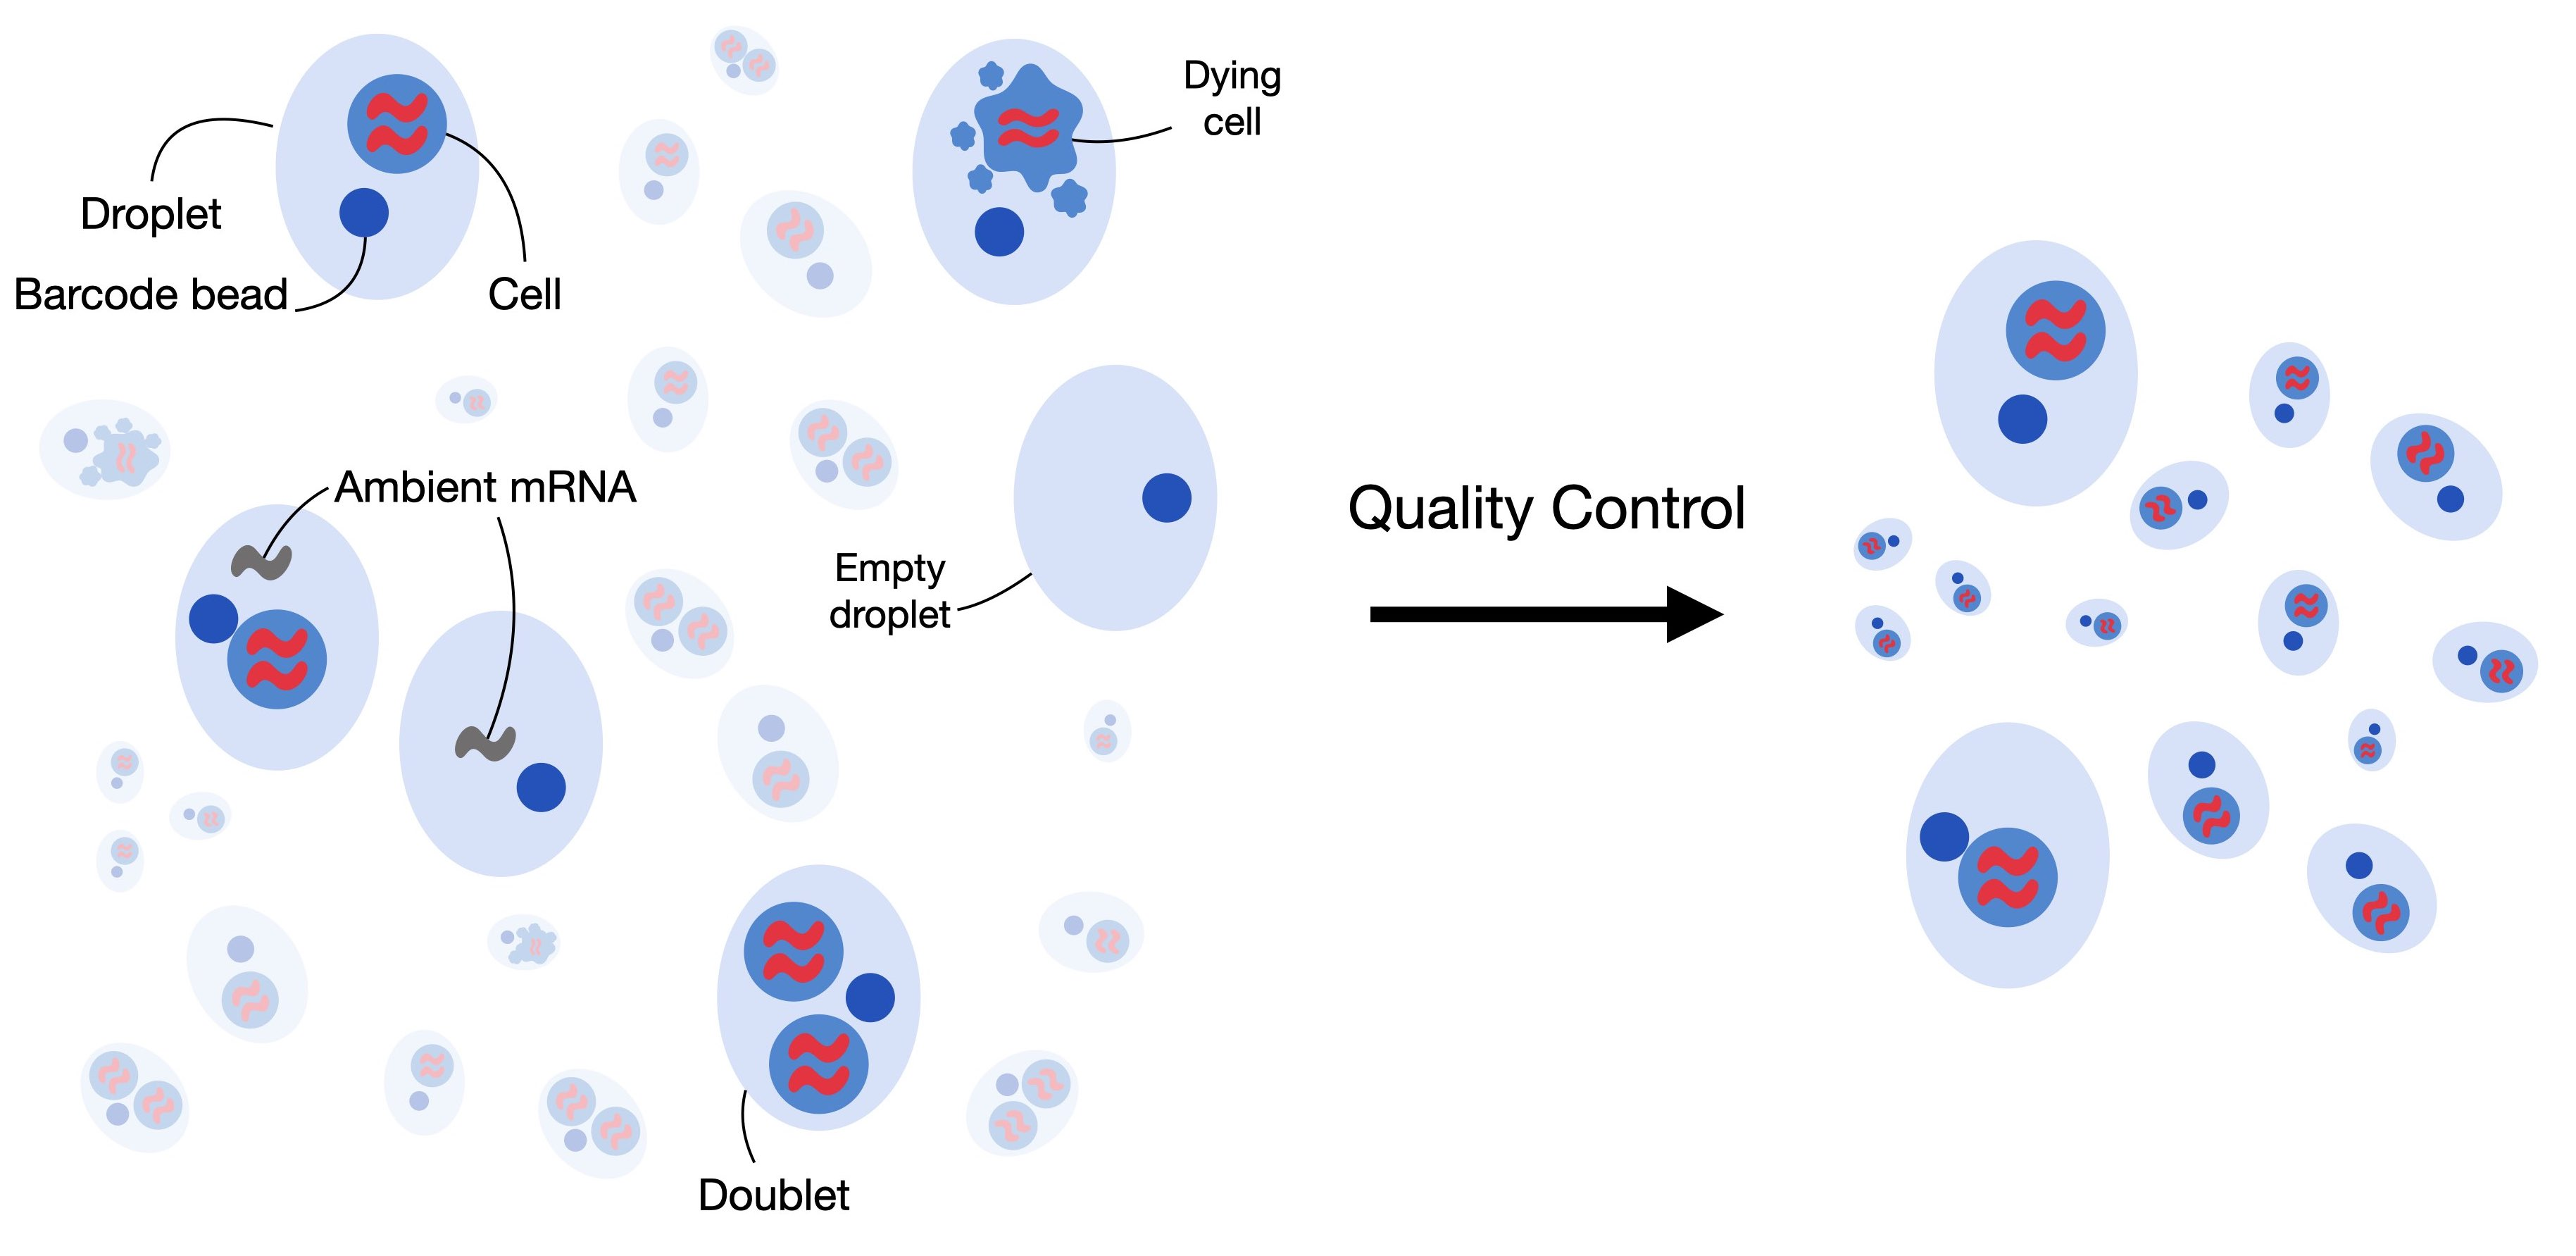

Obtenido de https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html

Para mostrar lo simple que puede ser este proceso, utilizaremos un set de datos generados con la tecnologia de 10x y mapeados con cellranger (v8.0.1), estos datos corresponden una muestra de un estudio de cancer de cabeza y cuello, disponibles en NCBI/SRA https://www.ncbi.nlm.nih.gov/sra/?term=SRR10340945.

In [ ]:
download.file("https://github.com/AdolfoRojas/scNotebooks-Resources/raw/refs/heads/main/SRR10340945-Cellranger_outs_Folder.tar.gz","SRR10340945-Cellranger_outs_Folder.tar.gz")
shell_call("tar -xvzf SRR10340945-Cellranger_outs_Folder.tar.gz")
shell_call("ls -lh")

Como se puede observar en el siguiente codigo, para datos de 10x el proceso es tan simple como cargar la carpeta de resultados de obtenidad desde cellranger y ejecutar la funcion autoEstCont().

In [ ]:
library(SoupX)
library(DropletUtils)
set.seed(123)
sc = load10X("Mapped_SRR10340945/outs/")

#png("SoupX_SRR10340945.png", width = 1080, height = 1080)
sc = autoEstCont(sc)
#dev.off()

In [ ]:
rhoEst <- sc$fit$rhoEst
print(rhoEst) # Fraccion de contaminacion estimada

out = adjustCounts(sc, roundToInt = TRUE) # normalmente las cuentas usan numeros enteros, para compatibilidad posterior con otras herramientas aqui se redondea.
DropletUtils:::write10xCounts("./SRR10340945_clean",out) # para exportar los datos en una carpeta en el formato de los resultados de cellranger

In [ ]:
shell_call("ls -lh SRR10340945_clean")

Para datos en los que no se tenga acceso a la carpeta de salida de cellranger completa ("outs") o no sean generados con tecnologia de 10x, tambien se puede emplear SoupX implementando una serie de pasos alternativos, que involucran generar un clustering, dado que en la manera anterior, se utiliza el clustering generado por cellranger cuya informacion esta disponible en la carpeta "outs", ademas de las matrices de cuentas. 
En las siguientes lineas de codigo veras un ejemplo adaptado desde https://cellgeni.github.io/notebooks/html/new-10kPBMC-SoupX.html con los datos que recien empleamos. Lo indispensable es tener ambas matrices: matriz de cuentas filtradas y matriz de cuentas brutas.

In [ ]:
filt.matrix <- Read10X_h5("Mapped_SRR10340945/outs/SRR10340945.filtered_feature_bc_matrix.h5",use.names = T)
raw.matrix  <- Read10X_h5("Mapped_SRR10340945/outs/SRR10340945.raw_feature_bc_matrix.h5",use.names = T)
srat  <- CreateSeuratObject(counts = filt.matrix)
soup.channel  <- SoupChannel(raw.matrix, filt.matrix)
soup.channel

Ahora ejecutaremos los pasos de normalizacion hasta la clusterizacion requerida por SoupX, por simplicidad y rapidez utilizamos NormalizeData(), pero puedes reemplazar por SCTransform() como se implementaba en el tutorial que adaptamos si asi lo prefieres

In [ ]:
srat    <- NormalizeData(srat, verbose = F)
srat    <- FindVariableFeatures(srat, verbose = F)
srat    <- ScaleData(srat, verbose = F)
srat    <- RunPCA(srat, verbose = F)
srat    <- RunUMAP(srat, dims = 1:30, verbose = F)
srat    <- FindNeighbors(srat, dims = 1:30, verbose = F)
srat    <- FindClusters(srat, verbose = T)

Luego integramos la informacion obtenida desde el procesamiento con seurat al objeto SoupChannel antes definido

In [ ]:
meta    <- srat@meta.data
umap    <- srat@reductions$umap@cell.embeddings
soup.channel  <- setClusters(soup.channel, setNames(meta$seurat_clusters, rownames(meta)))
soup.channel  <- setDR(soup.channel, umap)

Finalmente ya podremos estimar la contaminacion y guardar nuestros datos corregidos

In [ ]:
soup.channel  <- autoEstCont(soup.channel)
adj.matrix  <- adjustCounts(soup.channel, roundToInt = T)
DropletUtils:::write10xCounts("SRR10340945_cleanV2", adj.matrix)

Otras herramientas con las que se puede implementar este proceso de corrección de RNA ambiental y de las que puedes buscar mas informacion si estas interesado son DecontX (PMID: 32138770) y CellBender (PMID: 37550580)